In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import pandas as pd

import sys

sys.path.append("..")

from src.conformal_prediction.utils import compute_coverage, compute_volume_ellipsoid

In [3]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 22}
    plt.rc("font", **font)

In [4]:
set_style()

In [5]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params


def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result


def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

# Conformal prediction regions with fixed output covariance

In [6]:
params_path = "params/evaluate_coverage_fixed.json"
input_path = "results/evaluate_coverage/fixed/"

In [7]:
results = load_list_with_pickle(input_path + "result.pkl")

In [8]:
params = reader(params_path)

{'solver': 'Newton-CG', 'loss_name': 'log_cosh', 'loss_params': {'alpha': 1.0}, 'kernel': 'laplacian', 'kernel_max': 1, 'data': {'sample_size': 500, 'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'lams': [0.001, 0.01, 0.1], 'rep_number': 100}


In [9]:
control_levels = list(results["prediction_regions"][params["lams"][0]].keys())

In [10]:
coverages = {
    lam: {
        control_level: [
            compute_coverage(
                results["prediction_regions"][lam][control_level][iter_index],
                results["new_outputs"][iter_index],
            )
            for iter_index in range(params["rep_number"])
        ]
        for control_level in control_levels
    }
    for lam in params["lams"]
}

In [11]:
coverage_proportions = {
    lam: {
        control_level: np.mean(np.array(coverages[lam][control_level]))
        for control_level in control_levels
    }
    for lam in params["lams"]
}

In [12]:
list(coverage_proportions[0.001].values())

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.99),
 np.float64(0.98),
 np.float64(0.96)]

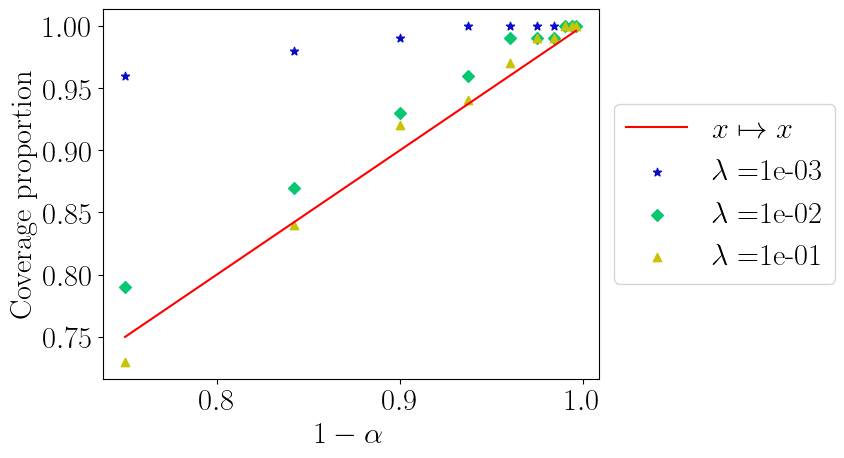

In [16]:
colors = ["#0808C7", "#08C771", "#C7C408"]
markers = ["*", "D", "^"]
fig, ax = plt.subplots()
iter = 0
ax.plot(
    1 - np.array(control_levels),
    1 - np.array(control_levels),
    color="red",
    label="$x \\mapsto x$",
)
for lam in params["lams"]:
    ax.scatter(
        1 - np.array(control_levels),
        np.array(list(coverage_proportions[lam].values())),
        marker=markers[iter],
        color=colors[iter],
        label=r"$\lambda =$" + "{}".format(format(lam, ".0e")),
    )
    iter += 1
ax.set_xlabel(r"$1 - \alpha$")
ax.set_ylabel("Coverage proportion")
# Put a legend below current axis
# Put a legend to the right of the current axis
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    

In [17]:
fig.savefig(
    input_path + "evaluate_coverage_fixed" + ".eps",
    format="eps",
    bbox_inches="tight",
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


In [18]:
fig.savefig(
    input_path + "evaluate_coverage_fixed" + ".jpeg",
    format="jpeg",
    bbox_inches="tight",
)